# Tutorial goals

This tutorial operationalizes Lecture Notes 2 with short, reproducible experiments.

You will:

1. Visualize activation behavior.
2. Explore gradients and chain rule numerically.
3. Compare learning rates in SGD.
4. Build intuition needed for Lab 2.


# Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)


# Exercise A: activation function behavior

Activation choices strongly shape optimization [@Goodfellow.Bengio.Courville.2016].


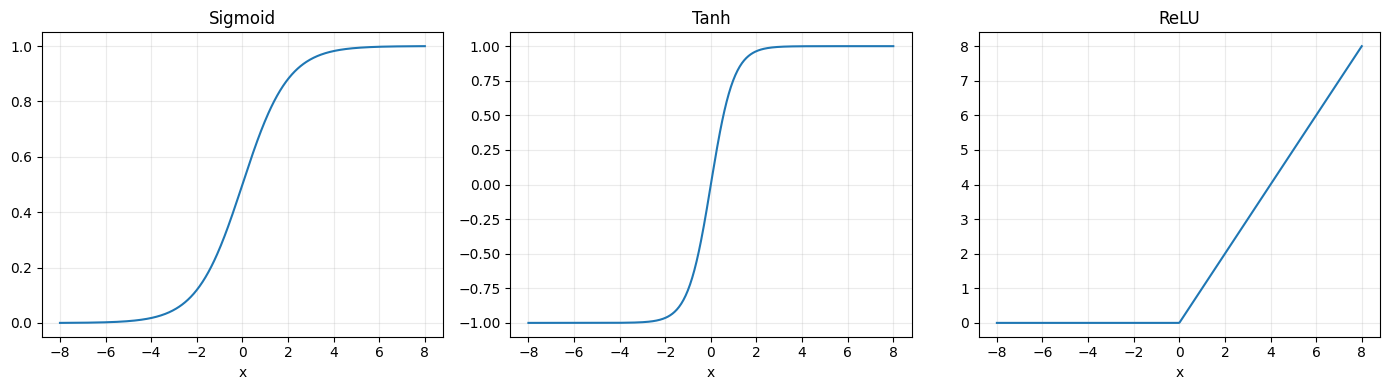

In [2]:
x = np.linspace(-8, 8, 500)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(x, sigmoid)
axes[0].set_title("Sigmoid")
axes[1].plot(x, tanh)
axes[1].set_title("Tanh")
axes[2].plot(x, relu)
axes[2].set_title("ReLU")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()


Quick interpretation:

1. Sigmoid and tanh saturate at large magnitudes.
2. ReLU is linear on positive inputs and zero on negative inputs.


# Exercise B: softmax and confidence


In [3]:
logits = torch.tensor([[2.0, 1.0, 0.1], [0.5, 0.5, 0.5], [5.0, 1.0, -2.0]])
probs = torch.softmax(logits, dim=1)

print("logits:\n", logits)
print("softmax probabilities:\n", probs)
print("row sums:", probs.sum(dim=1))


logits:
 tensor([[ 2.0000,  1.0000,  0.1000],
        [ 0.5000,  0.5000,  0.5000],
        [ 5.0000,  1.0000, -2.0000]])
softmax probabilities:
 tensor([[6.5900e-01, 2.4243e-01, 9.8566e-02],
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [9.8114e-01, 1.7970e-02, 8.9468e-04]])
row sums: tensor([1.0000, 1.0000, 1.0000])


Discussion:

1. Higher logit gaps lead to more confident distributions.
2. Softmax normalizes each row to sum to 1.


# Exercise C: chain rule intuition with autograd

This section links calculus to PyTorch autograd [@zhang2023d2l].


In [4]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1  # y = (x+1)^2

y.backward()
print("x:", x.item())
print("autograd dy/dx:", x.grad.item())
print("analytic dy/dx:", 2*x.item() + 2)


x: 3.0
autograd dy/dx: 8.0
analytic dy/dx: 8.0


# Exercise D: mini-batch SGD on linear regression


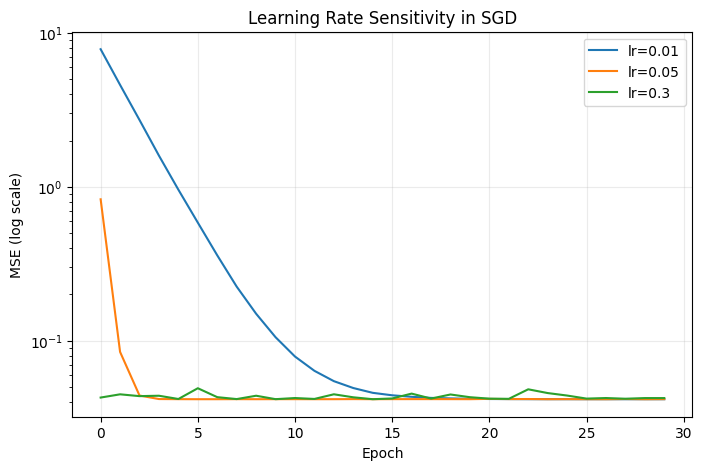

lr=0.01 -> w,b: 3.0 2.001
lr=0.05 -> w,b: 3.007 1.997
lr=0.30 -> w,b: 2.991 1.977


In [5]:
# Synthetic data: y = 3x + 2 + noise
n = 400
X = torch.randn(n, 1)
y = 3 * X + 2 + 0.2 * torch.randn(n, 1)

def train_sgd(lr=0.05, batch_size=32, epochs=30):
    w = torch.zeros((1, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X[idx], y[idx]

            pred = xb @ w + b
            loss = ((pred - yb)**2).mean()

            loss.backward()
            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()

        with torch.no_grad():
            full_loss = ((X @ w + b - y)**2).mean().item()
            losses.append(full_loss)
    return losses, w.detach().item(), b.detach().item()

losses_small, w_small, b_small = train_sgd(lr=0.01)
losses_mid, w_mid, b_mid = train_sgd(lr=0.05)
losses_large, w_large, b_large = train_sgd(lr=0.3)

plt.figure(figsize=(8, 5))
plt.plot(losses_small, label="lr=0.01")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_large, label="lr=0.3")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Sensitivity in SGD")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print("lr=0.01 -> w,b:", round(w_small, 3), round(b_small, 3))
print("lr=0.05 -> w,b:", round(w_mid, 3), round(b_mid, 3))
print("lr=0.30 -> w,b:", round(w_large, 3), round(b_large, 3))


Interpret using ideas from [@datacamp_sgd_tutorial]:

1. A low learning rate is stable but slower.
2. A moderate rate often converges fastest.
3. A high rate can oscillate and degrade progress.


# Exercise E: put activation into a tiny network


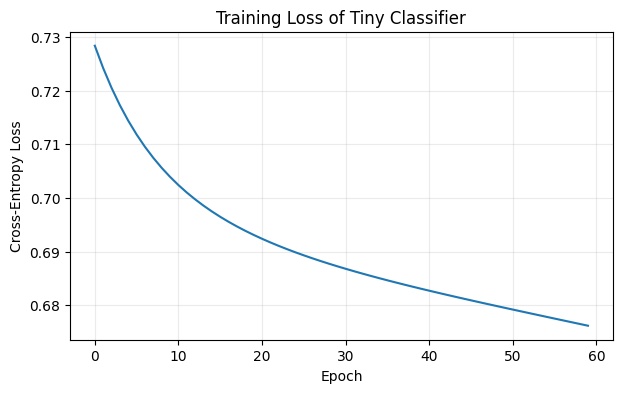

In [6]:
Xc = torch.randn(600, 2)
labels = (Xc[:, 0] * Xc[:, 1] > 0).long()  # nonlinear boundary

model = torch.nn.Sequential(
    torch.nn.Linear(2, 8),
    torch.nn.Tanh(),
    torch.nn.Linear(8, 2)
)

opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = torch.nn.CrossEntropyLoss()

history = []
for epoch in range(60):
    opt.zero_grad()
    logits = model(Xc)
    loss = loss_fn(logits, labels)
    loss.backward()
    opt.step()
    history.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.title("Training Loss of Tiny Classifier")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.25)
plt.show()


# Pre-lab checklist

Before starting Lab 2, verify that you can:

1. Explain one advantage and one limitation for each activation.
2. Explain mini-batch SGD update steps in words.
3. Identify a bad learning-rate pattern from a loss curve.


# References
